In [2]:
!apt-get update -qq
!apt-get install -y openjdk-17-jdk-headless
!java -version


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-17-jdk-headless is already the newest version (17.0.18+8-1~22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 24 not upgraded.
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


In [3]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] += ":/usr/lib/jvm/java-17-openjdk-amd64/bin"


In [4]:
!wget -q https://dlcdn.apache.org/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz
!tar -xzf hadoop-3.3.6.tar.gz
!mv hadoop-3.3.6 /content/hadoop


In [5]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["HADOOP_HOME"] = "/content/hadoop"
os.environ["HADOOP_CONF_DIR"] = "/content/hadoop/etc/hadoop"

os.environ["PATH"] += ":/content/hadoop/bin:/content/hadoop/sbin:/usr/lib/jvm/java-17-openjdk-amd64/bin"


In [6]:
!echo $JAVA_HOME
!java -version


/usr/lib/jvm/java-17-openjdk-amd64
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


In [7]:
%%writefile /content/hadoop/etc/hadoop/core-site.xml
<?xml version="1.0"?>
<configuration>
  <property>
    <name>fs.defaultFS</name>
    <value>hdfs://localhost:9000</value>
  </property>
</configuration>


Overwriting /content/hadoop/etc/hadoop/core-site.xml


In [8]:
%%writefile /content/hadoop/etc/hadoop/hdfs-site.xml
<?xml version="1.0"?>
<configuration>
  <property>
    <name>dfs.replication</name>
    <value>1</value>
  </property>

  <property>
    <name>dfs.namenode.name.dir</name>
    <value>file:///content/hadoop_tmp/dfs/name</value>
  </property>

  <property>
    <name>dfs.datanode.data.dir</name>
    <value>file:///content/hadoop_tmp/dfs/data</value>
  </property>
</configuration>


Overwriting /content/hadoop/etc/hadoop/hdfs-site.xml


In [9]:
!export JAVA_HOME=/usr/lib/jvm/java-17-openjdk-amd64
!export PATH=$JAVA_HOME/bin:$PATH


In [10]:
!sed -i 's|export JAVA_HOME=.*|export JAVA_HOME=/usr/lib/jvm/java-17-openjdk-amd64|' /content/hadoop/etc/hadoop/hadoop-env.sh
!grep JAVA_HOME /content/hadoop/etc/hadoop/hadoop-env.sh
# Set JAVA_HOME properly in Colab

#  JAVA_HOME=/usr/java/testing hdfs dfs -ls
# Technically, the only required environment variable is JAVA_HOME.
# export JAVA_HOME=/usr/lib/jvm/java-17-openjdk-amd64


In [11]:
import os
os.environ["HDFS_NAMENODE_USER"] = "root"
os.environ["HDFS_DATANODE_USER"] = "root"
os.environ["HDFS_SECONDARYNAMENODE_USER"] = "root"


In [12]:
!echo "export HDFS_NAMENODE_USER=root"       >> /content/hadoop/etc/hadoop/hadoop-env.sh
!echo "export HDFS_DATANODE_USER=root"       >> /content/hadoop/etc/hadoop/hadoop-env.sh
!echo "export HDFS_SECONDARYNAMENODE_USER=root" >> /content/hadoop/etc/hadoop/hadoop-env.sh
!grep HDFS_ /content/hadoop/etc/hadoop/hadoop-env.sh


## {YARN_xyz|HDFS_xyz} > HADOOP_xyz > hard-coded defaults
# export HDFS_AUDIT_LOGGER=INFO,NullAppender
# export HDFS_NAMENODE_OPTS="-Dcom.sun.management.jmxremote=true -Dcom.sun.management.jmxremote.authenticate=false -Dcom.sun.management.jmxremote.ssl=false -Dcom.sun.management.jmxremote.port=1026"
# export HDFS_NAMENODE_OPTS="${HADOOP_GC_SETTINGS} -Xloggc:${HADOOP_LOG_DIR}/gc-rm.log-$(date +'%Y%m%d%H%M')"
# export HDFS_NAMENODE_OPTS="-verbose:gc -XX:+PrintGCDetails -XX:+PrintGCTimeStamps -XX:+PrintGCDateStamps -Xloggc:${HADOOP_LOG_DIR}/gc-rm.log-$(date +'%Y%m%d%H%M')"
# export HDFS_NAMENODE_OPTS="-Dhadoop.security.logger=INFO,RFAS"
# export HDFS_SECONDARYNAMENODE_OPTS="-Dhadoop.security.logger=INFO,RFAS"
# export HDFS_DATANODE_OPTS="-Dhadoop.security.logger=ERROR,RFAS"
# export HDFS_DATANODE_SECURE_USER=hdfs
# export HDFS_DATANODE_SECURE_EXTRA_OPTS="-jvm server"
# export HDFS_NFS3_OPTS=""
# export HDFS_PORTMAP_OPTS="-Xmx512m"
# export HDFS_NFS3_SECURE_EXTRA_OPTS="-jvm server"
# expor

HDFS FIX


In [13]:
%%bash

cat > $HADOOP_HOME/etc/hadoop/core-site.xml <<EOF
<configuration>
    <property>
        <name>fs.defaultFS</name>
        <value>hdfs://localhost:9000</value>
    </property>
</configuration>
EOF

In [14]:
%%bash

cat > $HADOOP_HOME/etc/hadoop/hdfs-site.xml <<EOF
<configuration>
    <property>
        <name>dfs.replication</name>
        <value>1</value>
    </property>
    <property>
        <name>dfs.namenode.name.dir</name>
        <value>file:///tmp/hdfs/namenode</value>
    </property>
    <property>
        <name>dfs.datanode.data.dir</name>
        <value>file:///tmp/hdfs/datanode</value>
    </property>
</configuration>
EOF

In [15]:
!chmod +x /content/hadoop/etc/hadoop/hadoop-env.sh


In [16]:
!hdfs namenode -format


2026-03-31 16:41:09,203 INFO namenode.NameNode: STARTUP_MSG: 
/************************************************************
STARTUP_MSG: Starting NameNode
STARTUP_MSG:   host = b8413e84d4c1/172.28.0.12
STARTUP_MSG:   args = [-format]
STARTUP_MSG:   version = 3.3.6
STARTUP_MSG:   classpath = /content/hadoop/etc/hadoop:/content/hadoop/share/hadoop/common/lib/kerb-common-1.0.1.jar:/content/hadoop/share/hadoop/common/lib/jaxb-api-2.2.11.jar:/content/hadoop/share/hadoop/common/lib/jackson-mapper-asl-1.9.13.jar:/content/hadoop/share/hadoop/common/lib/kerb-client-1.0.1.jar:/content/hadoop/share/hadoop/common/lib/jetty-server-9.4.51.v20230217.jar:/content/hadoop/share/hadoop/common/lib/woodstox-core-5.4.0.jar:/content/hadoop/share/hadoop/common/lib/kerby-util-1.0.1.jar:/content/hadoop/share/hadoop/common/lib/jersey-server-1.19.4.jar:/content/hadoop/share/hadoop/common/lib/netty-codec-xml-4.1.89.Final.jar:/content/hadoop/share/hadoop/common/lib/kerby-asn1-1.0.1.jar:/content/hadoop/share/hadoop/

In [17]:
!$HADOOP_HOME/sbin/start-dfs.sh


Starting namenodes on [localhost]
ERROR: JAVA_HOME is not set and could not be found.
Starting datanodes
ERROR: JAVA_HOME is not set and could not be found.
Starting secondary namenodes [b8413e84d4c1]
ERROR: JAVA_HOME is not set and could not be found.


In [18]:
!hdfs --daemon start namenode
!hdfs --daemon start datanode
!hdfs --daemon start secondarynamenode


In [19]:
from pathlib import Path
import textwrap

conf_dir = Path("/content/hadoop/etc/hadoop")
conf_dir.mkdir(parents=True, exist_ok=True)

log4j = conf_dir / "log4j.properties"
log4j.write_text(textwrap.dedent("""
log4j.rootLogger=ERROR, console
log4j.appender.console=org.apache.log4j.ConsoleAppender
log4j.appender.console.target=System.err
log4j.appender.console.layout=org.apache.log4j.PatternLayout
log4j.appender.console.layout.ConversionPattern=%d{ISO8601} %-5p %c: %m%n
""").strip())

263

In [20]:
%%writefile /content/hadoop/etc/hadoop/core-site.xml
<?xml version="1.0"?>
<configuration>
  <property>
    <name>fs.defaultFS</name>
    <value>file:///</value>
  </property>
</configuration>

Overwriting /content/hadoop/etc/hadoop/core-site.xml


In [21]:
%%writefile /content/hadoop/etc/hadoop/hdfs-site.xml
<?xml version="1.0"?>
<configuration>
  <property>
    <name>dfs.replication</name>
    <value>1</value>
  </property>
</configuration>

Overwriting /content/hadoop/etc/hadoop/hdfs-site.xml


In [22]:
from pathlib import Path

hadoop_env = Path("/content/hadoop/etc/hadoop/hadoop-env.sh")
hadoop_env.write_text("export JAVA_HOME=/usr/lib/jvm/java-17-openjdk-amd64\n")

52

In [23]:
%%bash

export JAVA_HOME=/usr/lib/jvm/java-17-openjdk-amd64
export PATH=$JAVA_HOME/bin:$PATH

hdfs namenode -format

hdfs --daemon start namenode
hdfs --daemon start datanode

jps

5154 SecondaryNameNode
5018 NameNode
5083 DataNode
5292 Jps


namenode is running as process 5018.  Stop it first and ensure /tmp/hadoop-root-namenode.pid file is empty before retry.
namenode is running as process 5018.  Stop it first and ensure /tmp/hadoop-root-namenode.pid file is empty before retry.
datanode is running as process 5083.  Stop it first and ensure /tmp/hadoop-root-datanode.pid file is empty before retry.


HADOOP+JAVA SETUP 👆🏻

In [24]:
!pip install pyspark==3.3.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.4/281.4 MB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 14.5 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.3.2-py2.py3-none-any.whl size=281824009 sha256=7101b74a3f4ad4e9185113db95dc37dfa4aabc27d954b8cfe9f1e9a1b99636a8
  Stored in directory: /root/.cache/pip/wheels/93/99/74/4ba9a39bf51affed2cbf91a45688ea2a125775239338534f85
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.9
    Uninstalling py4j-0.10.9.9:
      Successfully uninstalled py4j-0.10.9.9
  Attempting uninstall: pyspark
    Found existing installation: pyspark 4.0.2
    Uninstalling pyspark-4.0.2:
      Successfully uninstalled pyspark-4.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-conn

spark Setup and verify


In [36]:
#creating the directory in HDFS
!hdfs dfs -mkdir -p /retail-data

#copying the file from Colab local storage TO HDFS
!hdfs dfs -put /content/retail_data.csv /retail-data/

#check if it's there
!hdfs dfs -ls /retail-data/

put: `/retail-data/retail_data.csv': File exists
Found 1 items
-rw-r--r--   1 root root    6118361 2026-03-31 16:45 /retail-data/retail_data.csv


In [48]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Retail Demand Forecasting") \
    .master("local[*]") \
    .getOrCreate()


In [41]:
!jps

7298 Jps
5018 NameNode
5083 DataNode
5884 SparkSubmit


In [50]:
df = spark.read.csv(
    "/retail-data/retail_data.csv",
    header=True,
    inferSchema=True
)

df.show(5)

+-------------------+--------+----------+-----------+------+---------------+----------+-------------+---------------+-----+--------+-----------------+-----------------+------------------+-----------+
|               Date|Store ID|Product ID|   Category|Region|Inventory Level|Units Sold|Units Ordered|Demand Forecast|Price|Discount|Weather Condition|Holiday/Promotion|Competitor Pricing|Seasonality|
+-------------------+--------+----------+-----------+------+---------------+----------+-------------+---------------+-----+--------+-----------------+-----------------+------------------+-----------+
|2022-01-01 00:00:00|    S001|     P0001|  Groceries| North|            231|       127|           55|         135.47| 33.5|      20|            Rainy|                0|             29.69|     Autumn|
|2022-01-01 00:00:00|    S001|     P0002|       Toys| South|            204|       150|           66|         144.04|63.01|      20|            Sunny|                0|             66.16|     Autumn|


cleaning the data

In [51]:
from pyspark.sql.functions import to_date

df = df.withColumn("Date", to_date(df["Date"], "yyyy-MM-dd"))

In [52]:
df = df.dropDuplicates()

In [53]:
df = df.dropna()

In [54]:
#changing the column names removing space etc
df = df.toDF(*[c.replace(" ", "_").replace("/", "_") for c in df.columns])

In [55]:
df = df.select(
    "Date",
    "Store_ID",
    "Product_ID",
    "Units_Sold",
    "Price",
    "Discount",
    "Holiday_Promotion",
    "Seasonality"
)

Data Aggregating

In [66]:
import pandas as pd

In [58]:
from pyspark.sql.functions import sum

daily_sales = df.groupBy("Date") \
                .agg(sum("Units_Sold").alias("Total_Sales")) \
                .orderBy("Date")

In [59]:
# Converting to pandas
pandas_df = daily_sales.toPandas()

pandas_df.rename(columns={
    "Date": "ds",
    "Total_Sales": "y"
}, inplace=True)

pandas_df = pandas_df.sort_values("ds")

pandas_df.head()

,ds,y
0,2022-01-01,14484
1,2022-01-02,13415
2,2022-01-03,13681
3,2022-01-04,14084
4,2022-01-05,12572


In [60]:
pandas_df = daily_sales.toPandas()

pandas_df.rename(columns={
    "Date": "ds",
    "Total_Sales": "y"
}, inplace=True)

pandas_df = pandas_df.sort_values("ds")

Feature engineering


In [92]:
from pyspark.sql.window import Window
from pyspark.sql.functions import lag

window = Window.partitionBy("Product_ID", "Store_ID").orderBy("Date")

df = df.withColumn("lag_1", lag("Units_Sold", 1).over(window))
df = df.withColumn("lag_7", lag("Units_Sold", 7).over(window))

In [93]:
from pyspark.sql.functions import avg

df = df.withColumn(
    "rolling_mean_7",
    avg("Units_Sold").over(window.rowsBetween(-7, 0))
)

In [67]:
pandas_df['ds'] = pd.to_datetime(pandas_df['ds'])

In [68]:
pandas_df['day_of_week'] = pandas_df['ds'].dt.dayofweek

.

In [69]:
df.filter(df.Store_ID == 1)

DataFrame[Date: date, Store_ID: string, Product_ID: string, Units_Sold: int, Price: double, Discount: int, Holiday_Promotion: int, Seasonality: string]

In [70]:
df.filter(df.Product_ID == 101)

DataFrame[Date: date, Store_ID: string, Product_ID: string, Units_Sold: int, Price: double, Discount: int, Holiday_Promotion: int, Seasonality: string]

In [71]:
train = pandas_df[:-30]
test = pandas_df[-30:]

In [72]:
!pip install prophet

In [85]:
from prophet import Prophet

#prophet expects columns: ds, y
model_prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model_prophet.fit(train)

#future dates
future = model_prophet.make_future_dataframe(periods=30)

forecast = model_prophet.predict(future)

#extract predictions
pred_prophet = forecast['yhat'][-30:].values

In [86]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train['y'], order=(5,1,0))
fit_arima = model_arima.fit()

pred_arima = fit_arima.forecast(steps=30)

In [87]:
pandas_df['y'].mean()

np.float64(13646.487004103967)

In [88]:
from sklearn.metrics import mean_absolute_error

mae_arima = mean_absolute_error(test['y'], pred_arima)
mae_prophet = mean_absolute_error(test['y'], pred_prophet)

print("ARIMA MAE:", mae_arima)
print("Prophet MAE:", mae_prophet)

ARIMA MAE: 976.0117136899165
Prophet MAE: 1006.9679711072789


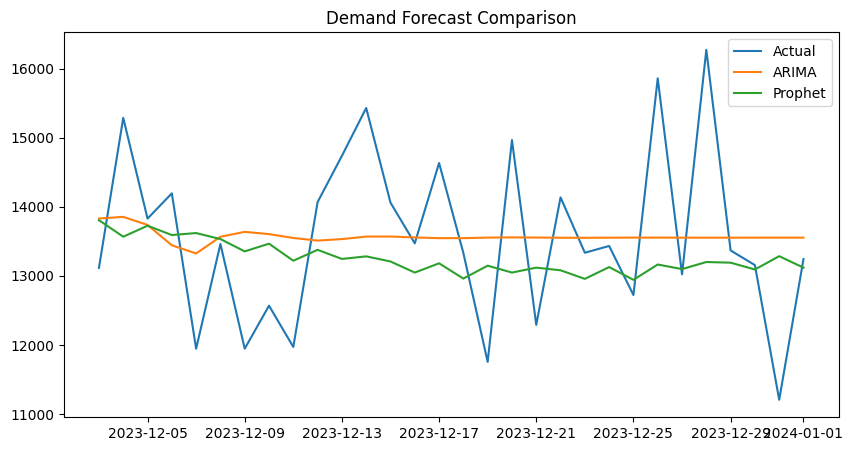

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(test['ds'], test['y'], label='Actual')
plt.plot(test['ds'], pred_arima, label='ARIMA')
plt.plot(test['ds'], pred_prophet, label='Prophet')

plt.legend()
plt.title("Demand Forecast Comparison")
plt.show()

In [94]:
df.head()

Row(Date=datetime.date(2022, 1, 1), Store_ID='S001', Product_ID='P0001', Units_Sold=127, Price=33.5, Discount=20, Holiday_Promotion=0, Seasonality='Autumn', lag_1=None, lag_7=None, rolling_mean_7=127.0)

In [75]:
!pip install xgboost

In [82]:
train = pandas_df[:-30]
test = pandas_df[-30:]

X_train = train.drop(columns=['y', 'ds'])
X_test = test.drop(columns=['y', 'ds'])


y_train = train['y']
y_test = test['y']

In [83]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor()
model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict(X_test)

In [90]:
from sklearn.metrics import mean_absolute_error

mae_xgb = mean_absolute_error(y_test, pred_xgb)

print("ARIMA MAE:", mae_arima)
print("Prophet MAE:", mae_prophet)
print("XGBoost MAE:", mae_xgb)

ARIMA MAE: 976.0117136899165
Prophet MAE: 1006.9679711072789
XGBoost MAE: 734.228271484375


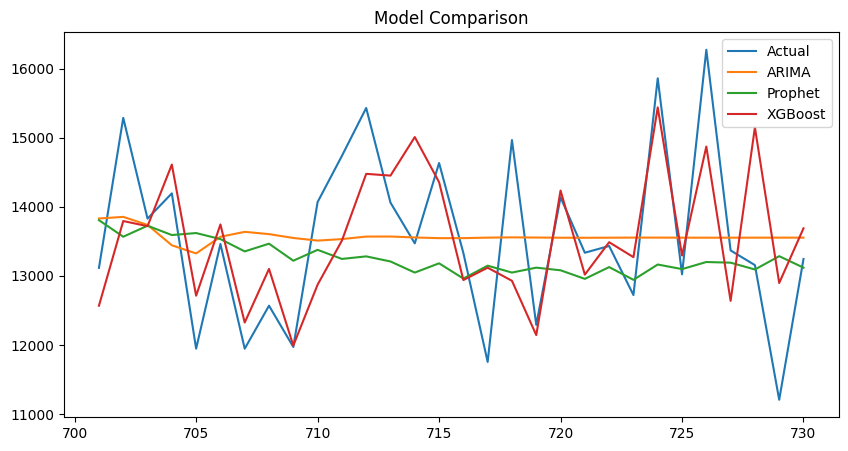

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(test.index, y_test, label='Actual')
plt.plot(test.index, pred_arima, label='ARIMA')
plt.plot(test.index, pred_prophet, label='Prophet')
plt.plot(test.index, pred_xgb, label='XGBoost')

plt.legend()
plt.title("Model Comparison")
plt.show()